# Tier 0 — Academic–Employer Reputation Gap: go / no-go

Proposal §7. Uses **only already-public, already-computed data** to test the most
failure-prone assumptions before any pipeline is built:

1. **AR (prestige)** — Wapman et al. 2022 SpringRank (Zenodo `10.5281/zenodo.6941651`).
2. **ER (earnings)** — College Scorecard Field-of-Study Bachelor's median earnings.
3. **Integration proxy** — SDR 2021 industry-employment share by field (fine field;
   SED broad field for the 3 humanities that SDR does not cover).

**Gap** (within field, across institutions):
`Gap_field = 1 − Spearman(prestige_rank, earnings_rank)`.

**GO requires all three:** (1) non-trivial cross-field SD of `Gap_field`;
(2) `Gap_field` correlates **negatively** with the integration proxy;
(3) computer science sits in the low-gap tail, below the median.

Heavy logic lives in `src/tier0.py`; crosswalks in `src/crosswalks/`. Data provenance:
`data/raw/SOURCES.md`. Run from the repo root.

In [1]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd()
if not (ROOT / "src").exists():          # if launched from notebooks/, step up
    ROOT = ROOT.parent
os.chdir(ROOT)                            # so relative data/output paths resolve
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from src import tier0 as T
from src.crosswalks import fields as F
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
print("repo root:", ROOT)

repo root: /home/soray/projects/Gap


## Step 1 — Academic reputation: Wapman SpringRank (Zenodo 6941651)

Archive `us-faculty-hiring-networks.zip` → `data/ranks.csv`. Schema:
`Rank, InstitutionId, InstitutionName, TaxonomyValue, TaxonomyLevel`. `Rank` is the
**SpringRank prestige ordinal** (0 = most prestigious) — confirmed by Caltech=0
academia-wide and Stanford=0 in CS (a prestige, not production, ordering). We read
`TaxonomyLevel == "Field"`. (Note: the GitHub README documents extra `PrestigeRank`
columns that live in `institution-stats.csv`; the per-institution ranks file we use
carries the prestige ordering in `Rank`.)

In [2]:
prestige = T.load_prestige()
print("prestige rows:", len(prestige), "| fields:", prestige.field_key.nunique())
print("\nComputer Science — most prestigious (Rank 0 = top):")
print(prestige[prestige.field_key == "computer_science"].nsmallest(6, "Rank")
      [["InstitutionName", "Rank"]].to_string(index=False))

prestige rows: 3676 | fields: 20

Computer Science — most prestigious (Rank 0 = top):
                      InstitutionName  Rank
                  Stanford University     0
   University of California, Berkeley     1
Massachusetts Institute of Technology     2
           Carnegie Mellon University     3
                   Cornell University     4
   California Institute of Technology     5


## Step 2 — Employer reputation: College Scorecard Field-of-Study earnings

`Most-Recent-Cohorts-Field-of-Study.csv` (release 2026-06-10), keyed by
`UNITID × CIPCODE(4-digit) × CREDLEV`. ER = **Bachelor's** (`CREDLEV==3`) median
earnings 4 years post-completion (`EARN_MDN_4YR`); suppressed cells `'PS'` → NaN.
The PhD-prestige vs undergraduate-earnings level mismatch is a documented Tier-0
caveat (and below we show institution-level PhD earnings are not publicly usable).

In [3]:
earnings = T.load_earnings(credlev="3", earn_col="EARN_MDN_4YR")
print("institution×field earnings cells:", len(earnings))
print("median matched-able institutions/field:",
      int(earnings.groupby('field_key').size().median()))

institution×field earnings cells: 7367
median matched-able institutions/field: 291


## Step 3 — Integration proxy: SDR 2021 industry-employment share by field

SDR Table 12-3 (`nsf23319`): Educational / Business-or-industry / Government **counts**
by ~98 fine fields → `industry_share = Business / All employed`. SDR is SEH-only, so
the 3 humanities fields fall back to SED Table 2-6 "Humanities and arts" broad share.

In [4]:
proxy = T.industry_share_table()
print(proxy.merge(pd.DataFrame(F.TIER0_FIELDS)[["key", "label"]],
                  left_on="field_key", right_on="key")
      [["label", "industry_share", "proxy_source"]]
      .sort_values("industry_share").to_string(index=False))

                 label  industry_share           proxy_source
               History        8.800000 SED broad (humanities)
            Philosophy        8.800000 SED broad (humanities)
               English        8.800000 SED broad (humanities)
             Sociology       20.766773               SDR fine
     Political Science       21.981424               SDR fine
          Anthropology       22.018349               SDR fine
           Mathematics       29.970326               SDR fine
             Economics       35.531136               SDR fine
        Earth Sciences       35.793358               SDR fine
               Biology       47.252747               SDR fine
            Psychology       48.684211               SDR fine
     Civil Engineering       53.164557               SDR fine
               Physics       55.910165               SDR fine
            Statistics       57.046980               SDR fine
             Chemistry       59.155991               SDR fine
      Co

## Step 4 — CIP ↔ Wapman-field crosswalk (20 fields spanning the range)

Centralized in `src/crosswalks/fields.py`. All 20 `wapman_field` labels are verified
present in the Wapman data; CIP-4 codes filter Scorecard; SDR fine-field labels drive
the proxy. CIP is the join key across sources.

In [5]:
xwalk = pd.DataFrame(F.TIER0_FIELDS)[["key", "label", "domain", "wapman_field", "cip4", "sdr_field"]]
print(xwalk.to_string(index=False))

                   key                  label                    domain                    wapman_field                     cip4                           sdr_field
      computer_science       Computer Science Mathematics and computing                Computer Science [1107, 1101, 1102, 1104]   Computer and information sciences
           mathematics            Mathematics Mathematics and computing                     Mathematics             [2701, 2703]          Mathematics and statistics
            statistics             Statistics Mathematics and computing                      Statistics                   [2705]          Mathematics and statistics
electrical_engineering Electrical Engineering               Engineering          Electrical Engineering                   [1410] Electrical and computer engineering
mechanical_engineering Mechanical Engineering               Engineering          Mechanical Engineering                   [1419]              Mechanical engineering
     civil

## Step 5 — Compute `Gap_field` for every field

In [6]:
gaps = T.all_field_gaps(prestige, earnings, min_n=8)
print(gaps[["label", "domain", "n_matched", "rho", "gap"]].to_string(index=False))

                 label                    domain  n_matched      rho      gap
            Statistics Mathematics and computing         28 0.753695 0.246305
      Computer Science Mathematics and computing        161 0.701728 0.298272
             Economics           Social sciences        116 0.687447 0.312553
     Political Science           Social sciences        139 0.656991 0.343009
Mechanical Engineering               Engineering        133 0.618015 0.381985
           Mathematics Mathematics and computing        120 0.612980 0.387020
               History                Humanities        131 0.586526 0.413474
            Psychology           Social sciences        173 0.572507 0.427493
             Sociology           Social sciences        114 0.569988 0.430012
  Chemical Engineering               Engineering         91 0.548145 0.451855
Electrical Engineering               Engineering        118 0.512913 0.487087
     Materials Science               Engineering         23 0.51

## Step 6 — Regress the gap on the integration proxy; plot (CS highlighted)

Proposal: `Gap_field ~ industry_share`. We report OLS on the full 20 fields and on the
consistently-measured SDR-only subset (dropping the different-universe humanities proxy),
plus the Spearman directions.

In [7]:
m = gaps[gaps.ok].merge(proxy, on="field_key").dropna(subset=["industry_share", "gap"])
m_sdr = m[m.proxy_source == "SDR fine"]
ols_all = smf.ols("gap ~ industry_share", data=m).fit()
ols_sdr = smf.ols("gap ~ industry_share", data=m_sdr).fit()
print("Spearman(gap, industry):  full = %.3f (p=%.3f);  SDR-only = %.3f (p=%.3f)"
      % (*spearmanr(m.industry_share, m.gap), *spearmanr(m_sdr.industry_share, m_sdr.gap)))
print("\nOLS gap ~ industry_share  [FULL 20]:    slope=%+.5f (p=%.3f),  R2=%.3f"
      % (ols_all.params['industry_share'], ols_all.pvalues['industry_share'], ols_all.rsquared))
print("OLS gap ~ industry_share  [SDR-only 17]: slope=%+.5f (p=%.3f),  R2=%.3f"
      % (ols_sdr.params['industry_share'], ols_sdr.pvalues['industry_share'], ols_sdr.rsquared))

Spearman(gap, industry):  full = -0.102 (p=0.667);  SDR-only = 0.022 (p=0.933)

OLS gap ~ industry_share  [FULL 20]:    slope=-0.00041 (p=0.776),  R2=0.005
OLS gap ~ industry_share  [SDR-only 17]: slope=+0.00039 (p=0.841),  R2=0.003


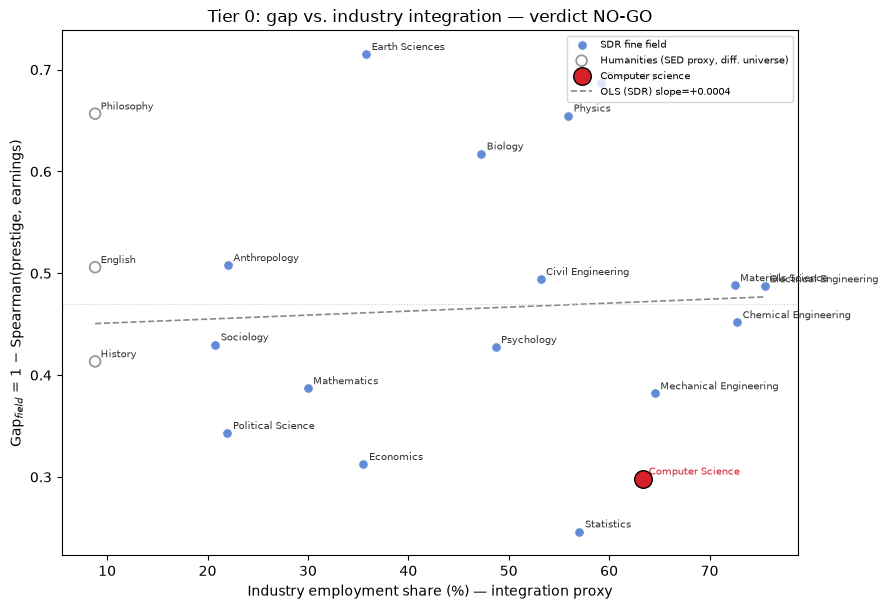

In [8]:
res = T.evaluate_go(gaps, proxy)
fig, ax = plt.subplots(figsize=(9, 6.2))
is_cs = m.field_key == F.HEADLINE_FIELD
is_hum = m.proxy_source != "SDR fine"
ax.scatter(m[~is_cs & ~is_hum].industry_share, m[~is_cs & ~is_hum].gap, s=46,
           c="#4878CF", alpha=.85, edgecolor="white", lw=.6, label="SDR fine field")
ax.scatter(m[is_hum].industry_share, m[is_hum].gap, s=60, facecolors="none",
           edgecolors="#999", lw=1.3, label="Humanities (SED proxy, diff. universe)")
ax.scatter(m[is_cs].industry_share, m[is_cs].gap, s=160, c="#D6202A",
           edgecolor="black", lw=1, zorder=5, label="Computer science")
for _, r in m.iterrows():
    ax.annotate(r.label, (r.industry_share, r.gap), fontsize=7.3, xytext=(4, 3),
                textcoords="offset points",
                color="#D6202A" if r.field_key == F.HEADLINE_FIELD else "#333")
xs = np.linspace(m.industry_share.min(), m.industry_share.max(), 50)
ax.plot(xs, ols_sdr.params['Intercept'] + ols_sdr.params['industry_share'] * xs, "--",
        c="#888", lw=1.2, label=f"OLS (SDR) slope={ols_sdr.params['industry_share']:+.4f}")
ax.axhline(res["gap_median"], color="#ccc", lw=.8, ls=":")
ax.set_xlabel("Industry employment share (%) — integration proxy")
ax.set_ylabel(r"Gap$_{field}$ = 1 − Spearman(prestige, earnings)")
ax.set_title(f"Tier 0: gap vs. industry integration — verdict {res['verdict']}")
ax.legend(loc="upper right", fontsize=7.5)
fig.tight_layout(); plt.show()

## Step 7 — Evaluate the three GO conditions

In [9]:
print(f"(1) variation:  gap SD = {res['gap_sd']:.3f}  range = "
      f"[{res['gap_range'][0]:.3f}, {res['gap_range'][1]:.3f}]   -> "
      f"{'PASS' if res['cond1_variation'] else 'FAIL'}")
print(f"(2) mechanism:  Spearman(gap, industry) SDR-only = "
      f"{res['spearman_gap_vs_industry_sdr_only']:+.3f} (p={res['p_sdr_only']:.2f}); "
      f"full = {res['spearman_gap_vs_industry_all']:+.3f}   -> "
      f"{'PASS' if res['cond2_mechanism_negative'] else 'FAIL (not negative within consistently-measured fields)'}")
cr, n = res["cs_rank_of_n"]
print(f"(3) headline:   CS gap = {res['cs_gap']:.3f}, rank {cr}/{n}, "
      f"median = {res['gap_median']:.3f}   -> {'PASS' if res['cond3_cs_low_gap'] else 'FAIL'}")
print(f"\n  >>> VERDICT: {res['verdict']}  <<<")

(1) variation:  gap SD = 0.134  range = [0.246, 0.715]   -> PASS
(2) mechanism:  Spearman(gap, industry) SDR-only = +0.022 (p=0.93); full = -0.102   -> FAIL (not negative within consistently-measured fields)
(3) headline:   CS gap = 0.298, rank 2/20, median = 0.469   -> PASS

  >>> VERDICT: NO-GO  <<<


### Verdict — **NO-GO** (on the strict three-condition test), but a *narrow* one

- **(1) Variation — PASS.** Gaps span 0.25–0.72 with clear domain structure (math/
  computing + social science low; natural sciences high). H1 is not the failure point.
- **(3) CS headline — PASS, decisively.** CS is the 2nd-lowest gap of 20 (only Statistics
  lower), far below the median; it holds in every robustness spec (`scripts/tier0_robustness.py`).
- **(2) Mechanism — FAIL.** Within the consistently-measured SDR fine fields the gap does
  **not** fall with industry share (Spearman ≈ +0.02, slope ≈ 0). The faint full-sample
  negative is an artifact of 3 humanities points carried on a different-universe proxy.
  Engineering (high industry share **and** high gap) breaks the predicted direction.

The two **paper-defining** conditions pass; the failure is isolated to the **crudest,
explicitly-provisional proxy** (industry *employment share* ≠ the H2 task-distance
variable). Per the proposal's strict rule ("all three required; no-go on any failure →
stop and rethink") the verdict is **NO-GO** — meaning *do not proceed to the full
ORCID+OpenAlex pipeline yet*; first upgrade the mechanism test (real Gathmann–Schönberg
O\*NET task distance) and the ER measurement (institution-level PhD earnings are
unavailable — Scorecard doctoral coverage is 4/20 — so re-ground ER at the field level).
Full reasoning and next steps: `notes/TIER0_RESULT.md`.